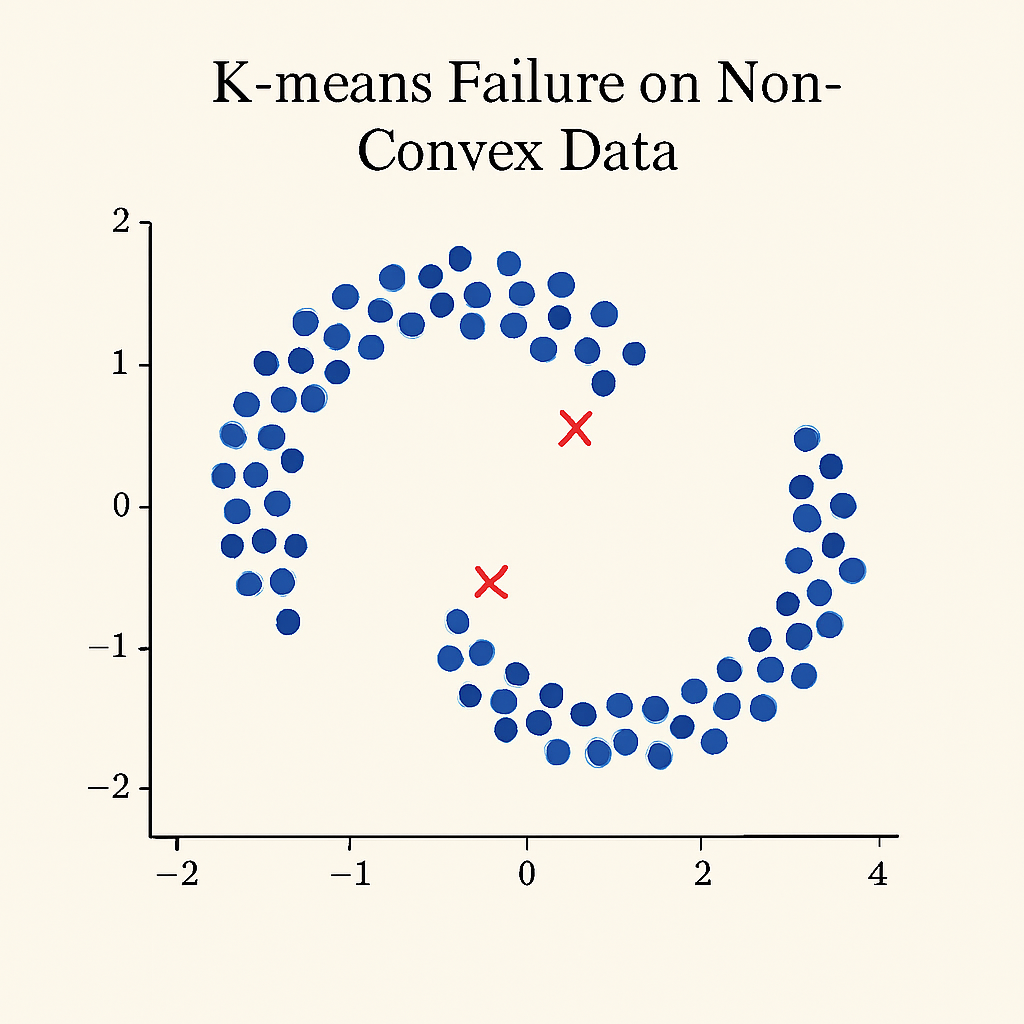

### 🔍 What This Shows
- The data consists of two **crescent-shaped clusters** (like two moons).
- K-means tries to split the data using **straight-line boundaries** based on Euclidean distance to centroids.
- As a result, it **incorrectly assigns points** from one crescent to the other, failing to capture the true shape.

### 🧠 Why This Happens
K-means assumes:
- Clusters are **convex** and roughly **spherical**.
- Boundaries are **linear** (Voronoi cells).
But non-convex shapes like moons, spirals, or nested rings violate these assumptions.

### ✅ Better Alternatives
To handle non-convex clusters, consider:
- **DBSCAN**: Density-based, handles arbitrary shapes.
- **Spectral Clustering**: Uses graph-based similarity.
- **Gaussian Mixture Models (GMMs)**: Soft assignments, more flexible.

Would you like to try clustering this same dataset using DBSCAN or Spectral Clustering and compare the results visually?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a powerful unsupervised learning algorithm designed to identify clusters of **arbitrary shape** and detect **outliers** in data. Here's a clear breakdown of how it works and why it's so useful:

---

### 🧠 Core Concepts of DBSCAN

| Concept        | Description |
|----------------|-------------|
| **ε (epsilon)** | Radius defining the neighborhood around a point |
| **MinPts**      | Minimum number of points required to form a dense region |
| **Core Point**  | A point with at least MinPts neighbors within ε |
| **Border Point**| A point within ε of a core point but with fewer than MinPts neighbors |
| **Noise Point** | A point that is neither a core nor border point |

---

### ⚙️ How DBSCAN Works

1. **Pick a point**: If it has ≥ MinPts neighbors within ε → it's a **core point**.
2. **Expand cluster**: Include all density-reachable points (connected via chains of core points).
3. **Repeat**: Continue until all points are classified.
4. **Label noise**: Points not reachable from any core point are labeled as **noise**.

---

### ✅ Advantages

- **No need to specify number of clusters** (unlike K-means).
- Handles **non-convex shapes** and **irregular densities**.
- Identifies **outliers** naturally.

---

### ❌ Limitations

- Sensitive to choice of ε and MinPts.
- Struggles with **varying density** across clusters.
- Not ideal for **high-dimensional data** without preprocessing.

---

### 📊 Example

Imagine a dataset with two crescent-shaped clusters. K-means would split them incorrectly due to its convex boundary assumption. DBSCAN, however, would correctly identify both crescents as separate clusters and ignore scattered noise points.

---

DBSCAN is especially useful in spatial data, anomaly detection, and any scenario where cluster shapes are unpredictable.  

### Spectral Clustering Explained  

Spectral clustering is a powerful **unsupervised learning technique** that leverages graph theory and linear algebra to group data points into clusters. Unlike traditional methods such as K-Means, which assume convex cluster shapes, spectral clustering excels at identifying **complex, non-convex structures**.  

---

#### 🔑 Core Idea
- Represent data as a **graph**:  
  Each data point is a node, and edges represent similarity (often based on distance or affinity).
- Build a **similarity matrix**:  
  A symmetric matrix where entry \(S_{ij}\) measures similarity between points \(i\) and \(j\).
- Compute the **graph Laplacian**:  
  Derived from the similarity matrix, it encodes connectivity and structure of the graph.
- Perform **eigen-decomposition**:  
  Extract eigenvalues and eigenvectors of the Laplacian. These capture the graph’s structural properties.
- Cluster in the reduced space:  
  Use a standard algorithm (often K-Means) on the selected eigenvectors to form clusters.  [GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/spectral-clustering-a-comprehensive-guide-for-beginners/)  [Great Learning](https://www.mygreatlearning.com/blog/introduction-to-spectral-clustering/)  [Wikipedia](https://en.wikipedia.org/wiki/Spectral_clustering)  

---

#### 🧮 Step-by-Step Process
1. **Construct similarity matrix** $W$ using a kernel (e.g., Gaussian kernel).  
2. **Compute degree matrix** $D$, where $D_{ii} = \sum_j W_{ij}$.  
3. **Form Laplacian**:  
   - Unnormalized: $L = D - W$  
   - Normalized: $L_{sym} = D^{-1/2} L D^{-1/2}$  
4. **Find eigenvectors** of $L$.  
5. **Select top $k$ eigenvectors** (corresponding to smallest eigenvalues).  
6. **Cluster rows** of the eigenvector matrix using K-Means.  

---

#### 📊 Comparison with K-Means

| Aspect                | K-Means                          | Spectral Clustering |
|------------------------|----------------------------------|---------------------|
| Cluster shape          | Convex, spherical                | Arbitrary, non-convex |
| Input                  | Raw data points                  | Similarity graph / Laplacian |
| Strengths              | Fast, simple                     | Handles complex structures |
| Weaknesses             | Struggles with irregular shapes  | Requires eigen-decomposition |

---

#### 🌍 Applications
- **Image segmentation** (separating objects in images)  
- **Social network analysis** (detecting communities)  
- **Biological data clustering** (gene expression patterns)  
- **Recommendation systems** (grouping similar users/items)  

---


---

### Example: Two Concentric Circles

Suppose we have 8 points arranged on two concentric circles:

- Inner circle: \((1,0), (0,1), (-1,0), (0,-1)\)  
- Outer circle: \((2,0), (0,2), (-2,0), (0,-2)\)

Clearly, there are **two clusters** (inner vs. outer circle), but notice:  
- K-Means would struggle because both clusters are centered at the origin.  
- Spectral clustering can separate them by graph connectivity.

---

#### Step 1: Construct Similarity Matrix \(W\)
We use a Gaussian kernel:

$
W_{ij} = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right)
$

This makes points close together highly connected, far points weakly connected.

---

#### Step 2: Degree Matrix \(D\)
$
D_{ii} = \sum_j W_{ij}
$

Each diagonal entry is the sum of similarities for point \(i\).

---

#### Step 3: Graph Laplacian
Unnormalized Laplacian:

$
L = D - W
$

Normalized Laplacian:

$
L_{sym} = D^{-1/2} L D^{-1/2}
$

---

#### Step 4: Eigen-Decomposition
- Compute eigenvalues and eigenvectors of \(L_{sym}\).  
- The **smallest eigenvalues** correspond to connected components.  
- Here, the eigenvectors split points into two groups: inner vs. outer circle.

---

#### Step 5: Cluster in Eigenvector Space
- Take the first \(k=2\) eigenvectors.  
- Each point is represented by its coordinates in this reduced space.  
- Apply K-Means → points on the inner circle form one cluster, outer circle another.

---

### Intuition
- The Laplacian encodes connectivity.  
- Inner circle points are more connected to each other than to outer circle points.  
- Eigenvectors of the Laplacian highlight this separation.  

---

✅ Result: Spectral clustering correctly identifies **two clusters**, even though they overlap in Euclidean space.

---

The **Gaussian Kernel**, also known as the **Radial Basis Function (RBF) kernel**, is a mathematical function used to measure the similarity between two data points. It is most famous for its role in **Support Vector Machines (SVMs)** and **Image Processing** (Gaussian Blur).

At its core, it assigns a high value to points that are close to each other and a value approaching zero as points move further apart.

---

### 1. The Mathematical Formula

For two points  and , the Gaussian Kernel is defined as:

Where:

*  is the **Squared Euclidean Distance** between the points.
*  (Sigma) is the **bandwidth** or "spread." It controls how quickly the influence of a point dies off.
* Sometimes written using  (Gamma), where .

---

### 2. How it Works (The "Similarity" Concept)

Think of the Gaussian Kernel as a "soft" proximity sensor:

* **Identical points:** If , the distance is 0, and . The similarity is at its maximum.
* **Near points:** As distance increases slightly, the value drops slowly.
* **Far points:** As distance becomes large, the value drops exponentially toward 0.

---

### 3. Key Use Cases

#### A. Support Vector Machines (The "Kernel Trick")

In machine learning, data is often not linearly separable in 2D or 3D space. The Gaussian Kernel acts as a "bridge" that implicitly projects data into an **infinite-dimensional space**.

* It allows the SVM to create complex, curved decision boundaries that can wrap around clusters of data.
* This is known as the **Kernel Trick** because we calculate the similarity in high dimensions without actually performing the expensive transformation of the coordinates.

#### B. Image Processing (Gaussian Blur)

In computer vision, a Gaussian Kernel is used as a "sliding window" (convolution matrix) over an image.

* The center pixel gets the highest weight, and surrounding pixels get lower weights based on the Gaussian curve.
* This effectively averages pixels together, reducing noise and creating a smooth blurring effect.

---

### 4. The Role of  (Bandwidth)

The parameter  is the most important "knob" to turn:

* **Small :** The curve is very "spiky." Only points extremely close to each other are considered similar. This can lead to **overfitting** (the model follows the noise).
* **Large :** The curve is "flat." Points far away still influence each other. This can lead to **underfitting** (the model is too blurry or smooth).

---

### Summary Table

| Feature | Gaussian Kernel (RBF) |
| --- | --- |
| **Shape** | Bell-shaped curve |
| **Range** | Always between 0 and 1 |
| **Hyperparameter** |  (Sigma) or  (Gamma) |
| **Main Strength** | Handles non-linear data exceptionally well |


## Implement Guassian Kernel

In [2]:
# Implement using sklearn
from sklearn.svm import SVC
import numpy as np

# Sample data
X = np.array([[1,2],[5,8],[1.5, 1.8],[8,8]])
y = [0, 1, 0, 1]

model = SVC(kernel="rbf", gamma=0.7)

model.fit(X,y)

print("Predict for [2,2]:", model.predict([[2,2]]))
print("Predict for [9,9]:", model.predict([[9,9]]))

Predict for [2,2]: [0]
Predict for [9,9]: [1]


In [3]:
from sklearn.metrics.pairwise import rbf_kernel

# Computes exp(-gamma * ||x-y||^2)
kernel_matrix = rbf_kernel(X, gamma=0.1)
print(kernel_matrix)

[[1.00000000e+00 5.51656442e-03 9.71416464e-01 2.03468369e-04]
 [5.51656442e-03 1.00000000e+00 6.28870570e-03 4.06569660e-01]
 [9.71416464e-01 6.28870570e-03 1.00000000e+00 3.13096221e-04]
 [2.03468369e-04 4.06569660e-01 3.13096221e-04 1.00000000e+00]]


In [11]:
# Implement Gaussian Kernel using Numpy

# Implements Similarity score for two points in Nth dimension
import numpy as np

def gaussian_kernel(x1, x2, sigma=1.0):
    distance = np.linalg.norm(x1 - x2)**2

    return np.exp(-distance / (2*(sigma**2)))

# Points in 3-Dimensional space
X1 = np.array([1, 2, 3])
X2 = np.array([1, 2, 2.9])

print(gaussian_kernel(X1, X2, 0.7))

0.9898478033787338


In [19]:
X = np.random.rand(5, 2)
print(X)
print(X**2)
sq_norms = np.sum(X**2, axis=1).reshape(-1,1)

sq_norms

[[0.9042748  0.2731605 ]
 [0.81282986 0.68560721]
 [0.83873286 0.53156769]
 [0.66325944 0.66990531]
 [0.24899415 0.67731674]]
[[0.81771291 0.07461666]
 [0.66069239 0.47005725]
 [0.70347281 0.28256421]
 [0.43991308 0.44877312]
 [0.06199809 0.45875797]]


array([[0.89232957],
       [1.13074964],
       [0.98603702],
       [0.8886862 ],
       [0.52075605]])

In [20]:
def vectorized_rbf_kernel(X, gamma=0.1):
    # Calculate squared norms of each row
    sq_norms = np.sum(X**2, axis=1).reshape(-1, 1)
    
    # Pairwise squared distances: ||x-y||^2 = ||x||^2 + ||y||^2 - 2x.T@y
    dists = sq_norms + sq_norms.T - 2 * np.dot(X, X.T)
    
    return np.exp(-gamma * dists)

In [21]:
print(vectorized_rbf_kernel(X))

[[1.         0.98231088 0.99291819 0.97868105 0.94244897]
 [0.98231088 1.         0.99756306 0.99774077 0.96870229]
 [0.99291819 0.99756306 1.         0.99501962 0.96376918]
 [0.97868105 0.99774077 0.99501962 1.         0.98297945]
 [0.94244897 0.96870229 0.96376918 0.98297945 1.        ]]
